# Abalone Project

## 3. Построение моделей

Импортируем базовые библиотеки

In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
seed=124
import warnings
warnings.filterwarnings('ignore')

Загрузим очищенный датасет

In [6]:
df = pd.read_csv('abalon_clean.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      4177 non-null   int64  
 1   Sex             4177 non-null   object 
 2   Length          4177 non-null   float64
 3   Diameter        4177 non-null   float64
 4   Height          4177 non-null   float64
 5   Whole weight    4177 non-null   float64
 6   Shucked weight  4177 non-null   float64
 7   Viscera weight  4177 non-null   float64
 8   Shell weight    4177 non-null   float64
 9   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 326.5+ KB


In [8]:
df.drop('Unnamed: 0',axis=1,inplace=True)

**Построение моделей на числовых признаках**

Посмотрим на целевую переменную - возраст моллюсков

In [11]:
y = df['Rings']

<Axes: xlabel='Rings', ylabel='Count'>

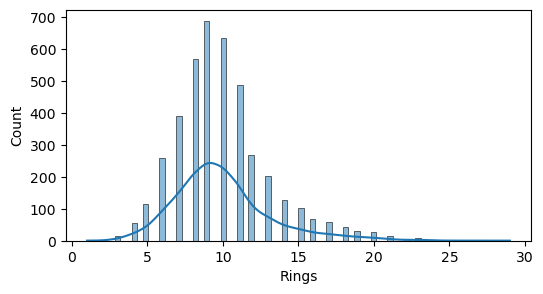

In [12]:
plt.figure(figsize=(6,3))
sns.histplot(data = y, kde = True)

Определим медианное значение целевой переменной, затем разделим весь датасет на более-менее равные группы: молодые моллюски и старые, чтобы в дальнейшем решать задачу классификации.

In [14]:
y.median()

9.0

In [15]:
y_class = (y > 9).astype(int)
y_class.value_counts()

Rings
0    2096
1    2081
Name: count, dtype: int64

Выделим числовые признаки

In [17]:
X=df.iloc[:, 1:8]
X.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,0.440,0.365,0.125,0.7985,0.2155,0.1140,0.155
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


Разделим датасет на тренировочную и тестовую части и проанализируем показатели по 5 моделям классификации

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.25, random_state=seed)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve,roc_auc_score,classification_report, auc, ConfusionMatrixDisplay

In [21]:
def evaluate_model(model, x_test, y_test):
    # Predict Test Data 
    y_pred = model.predict(x_test)

    # Calculate accuracy, precision, recall, f1-score, and kappa score
    acc = accuracy_score(y_test, y_pred)
        
    # Calculate area under curve (AUC)
    y_pred_proba = model.predict_proba(x_test)[::,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Display confussion matrix
    cm = confusion_matrix(y_test, y_pred)

    return {'acc': acc, 'fpr': fpr, 'tpr': tpr, 'auc': auc, 'cm': cm}

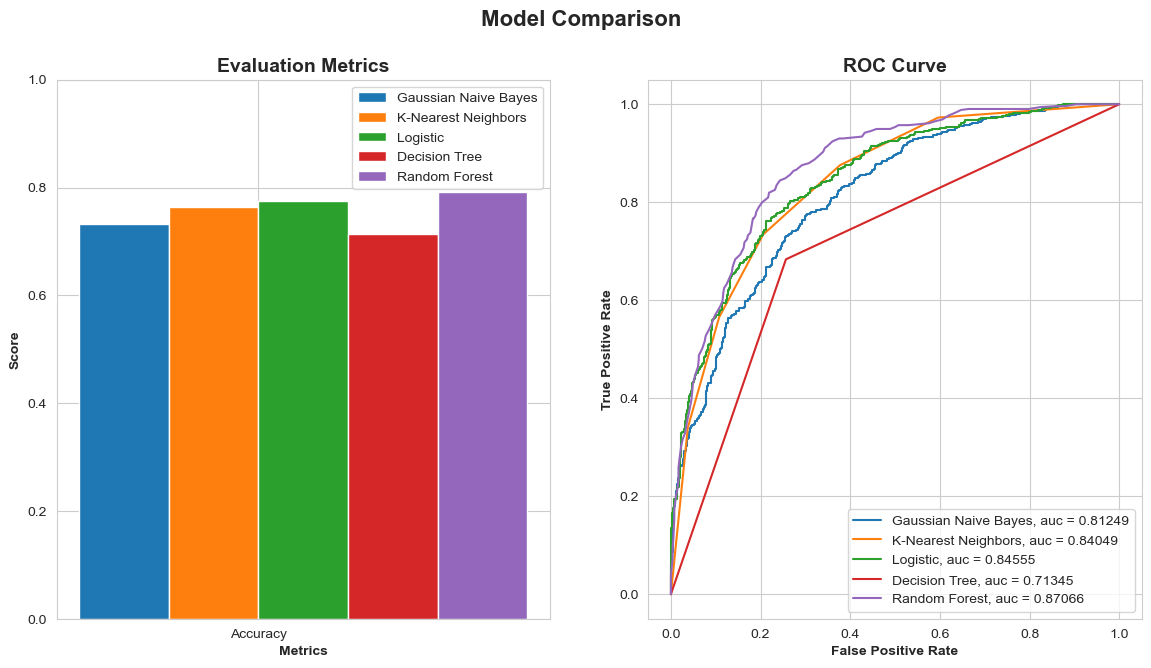

In [22]:
gnb = GaussianNB()
knn=KNeighborsClassifier()
logreg=LogisticRegression(random_state=seed)
tree=DecisionTreeClassifier(random_state=seed)
rtree=RandomForestClassifier(random_state=seed)

# fitting models
gnb.fit(X_train, y_train)
gnb_eval = evaluate_model(gnb, X_test, y_test)

knn.fit(X_train, y_train)
knn_eval = evaluate_model(knn, X_test, y_test)

logreg.fit(X_train, y_train)
logreg_eval = evaluate_model(logreg, X_test, y_test)

tree.fit(X_train, y_train)
tree_eval = evaluate_model(tree, X_test, y_test)

rtree.fit(X_train, y_train)
rtree_eval = evaluate_model(rtree, X_test, y_test)

# Intitialize figure with two plots
sns.set_style('whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')
fig.set_figheight(7)
fig.set_figwidth(14)
fig.set_facecolor('white')

# First plot
## set bar size
barWidth = 0.2
gnb_score = [gnb_eval['acc']]
knn_score = [knn_eval['acc']]
logreg_score = [logreg_eval['acc']]
tree_score = [tree_eval['acc']]
rtree_score = [rtree_eval['acc']]

## Set position of bar on X axis
r1 = np.arange(len(logreg_score))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]
r5 = [x + barWidth for x in r4]

## Make the plot
ax1.bar(r1, gnb_score, width=barWidth, edgecolor='white', label='Gaussian Naive Bayes')
ax1.bar(r2, knn_score, width=barWidth, edgecolor='white', label='K-Nearest Neighbors')
ax1.bar(r3, logreg_score, width=barWidth, edgecolor='white', label='Logistic')
ax1.bar(r4, tree_score, width=barWidth, edgecolor='white', label='Decision Tree')
ax1.bar(r5, rtree_score, width=barWidth, edgecolor='white', label='Random Forest')

## Configure x and y axis
ax1.set_xlabel('Metrics', fontweight='bold')
labels = ['Accuracy']
ax1.set_xticks([r + (barWidth * 1.5) for r in range(len(logreg_score))], )
ax1.set_xticklabels(labels)
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_ylim(0, 1)

## Create legend & title
ax1.set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
ax1.legend()

# Second plot
## Comparing ROC Curve
ax2.plot(gnb_eval['fpr'], gnb_eval['tpr'], label='Gaussian Naive Bayes, auc = {:0.5f}'.format(gnb_eval['auc']))
ax2.plot(knn_eval['fpr'], knn_eval['tpr'], label='K-Nearest Neighbors, auc = {:0.5f}'.format(knn_eval['auc']))
ax2.plot(logreg_eval['fpr'], logreg_eval['tpr'], label='Logistic, auc = {:0.5f}'.format(logreg_eval['auc']))
ax2.plot(tree_eval['fpr'], tree_eval['tpr'], label='Decision Tree, auc = {:0.5f}'.format(tree_eval['auc']))
ax2.plot(rtree_eval['fpr'], rtree_eval['tpr'], label='Random Forest, auc = {:0.5f}'.format(rtree_eval['auc']))

## Configure x and y axis
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')

## Create legend & title
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc=4)

plt.show()

Согласно графику 3 модели показывают лучшие рельтаты: логическая регрессия, метод ближайших соседей и случайный лес.

In [24]:
from sklearn.model_selection import cross_val_score
cross_val_score(knn, X, y_class, scoring='accuracy', cv=3, n_jobs=-1).mean()

0.7740008540238136

In [25]:
from sklearn.model_selection import cross_val_score
cross_val_score(rtree, X, y_class, scoring='accuracy', cv=3, n_jobs=-1).mean()

0.7931502064234692

In [26]:
from sklearn.model_selection import cross_val_score
cross_val_score(logreg, X, y_class, scoring='accuracy', cv=3, n_jobs=-1).mean()

0.7696929158655896

По кросс-валидации лучшие результаты дают модели ближайших соседей и случайный лес, поэтому в дальнейшем я буду подбирать гиперпараметры по этим двум моделям.

**Подбор гиперпараметров у моделей**

In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
params = {'n_neighbors' : np.arange(2, 20, 2),
          'weights' : ['uniform', 'distance'],
          'p' : [1, 2]}
gs = GridSearchCV(knn, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)
gs.best_score_, gs.best_params_

Fitting 3 folds for each of 36 candidates, totalling 108 fits


(0.793742017879949, {'n_neighbors': 18, 'p': 1, 'weights': 'distance'})

In [31]:
pred = knn.predict(X_test)
accuracy_score(y_test, pred)

0.7645933014354067

In [32]:
pred = gs.best_estimator_.predict(X_test)
accuracy_score(y_test, pred)

0.7866028708133971

После подбора гиперпараметров метрика accuracy у модели ближайших соседей на тренировочном датасете улучшилась приблизительно на 0,02 пункта.

In [34]:
params = {
    "max_depth":[1,2,3,5,6,7, None],
    "n_estimators":[50,100,200,300] ,
    "max_features" : ['auto', 'sqrt']
    }
gs1 = GridSearchCV(rtree, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)
gs1.fit(X_train, y_train)
gs1.best_score_, gs1.best_params_

Fitting 3 folds for each of 56 candidates, totalling 168 fits


(0.7940613026819924,
 {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 200})

In [35]:
pred = rtree.predict(X_test)
accuracy_score(y_test, pred)

0.7923444976076555

In [36]:
pred = gs1.best_estimator_.predict(X_test)
accuracy_score(y_test, pred)

0.7866028708133971

После подбора гиперпараметров метрика accuracy у модели случайного леса на тренировочном датасете ухудшилась.

**Добавление категориальных признаков в лучшую модель**

У нас один категориальный признак - пол моллюска

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [41]:
df.Sex.value_counts(normalize=True)

Sex
F    0.348097
M    0.346421
I    0.305482
Name: proportion, dtype: float64

In [42]:
X_full=df.iloc[:,0:8]
X_full.head(1)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15


In [43]:
cols=list(X_full.columns)
cols[1:]

['Length',
 'Diameter',
 'Height',
 'Whole weight',
 'Shucked weight',
 'Viscera weight',
 'Shell weight']

Разделим датасет с категориальным признаком на тренировочную и тестовую части, трансформируем колонки (нормализуем числовые колонки и закодируем наш категориальный признак)

In [45]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_class, test_size=0.25, random_state=seed)

In [46]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

categorical = ['Sex']
numeric_features = cols[1:]

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', MinMaxScaler(), numeric_features)
])

X_train_transformed = ct.fit_transform(X_train_full)
X_test_transformed = ct.transform(X_test_full)

In [47]:
new_features = list(ct.named_transformers_['ohe'].get_feature_names_out())
new_features.extend(numeric_features)

new_features

['Sex_F',
 'Sex_I',
 'Sex_M',
 'Length',
 'Diameter',
 'Height',
 'Whole weight',
 'Shucked weight',
 'Viscera weight',
 'Shell weight']

In [48]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=new_features)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=new_features)
X_train_transformed.head()

,Sex_F,Sex_I,Sex_M,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,1.0,0.0,0.0,0.560811,0.529412,0.123894,0.206481,0.162744,0.150757,0.192825
1,1.0,0.0,0.0,0.729730,0.705882,0.146018,0.282097,0.329186,0.256748,0.300947
2,1.0,0.0,0.0,0.608108,0.630252,0.110619,0.282097,0.222260,0.217907,0.175386
3,0.0,0.0,1.0,0.837838,0.865546,0.203540,0.666903,0.582044,0.572087,0.496761
4,1.0,0.0,0.0,0.641892,0.605042,0.119469,0.273774,0.202421,0.235023,0.257598


In [49]:
model = KNeighborsClassifier()

params = {'n_neighbors' : np.arange(2, 20, 2),
          'weights' : ['uniform', 'distance']}

gs = GridSearchCV(model, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=5)
gs.fit(X_train_transformed, y_train_full)
gs.best_score_, gs.best_params_

Fitting 3 folds for each of 18 candidates, totalling 54 fits


(0.7755427841634739, {'n_neighbors': 18, 'weights': 'uniform'})

In [50]:
pred = gs.best_estimator_.predict(X_test_transformed)
accuracy_score(y_test_full, pred)

0.7751196172248804

После подбора гиперпараметров и включения категориального признака в модель ближайших соседей, метрика accuracy упала с 78,66% до 77,51%.

In [52]:
model = RandomForestClassifier(random_state=seed)
params = {
    "max_depth":[1,2,3,5,6,7, None],
    "n_estimators":[50,100,200,300] ,
    "max_features" : ['auto', 'sqrt']
    }
gs = GridSearchCV(model, params, scoring='accuracy', cv=3, n_jobs=-1, verbose=5)
gs.fit(X_train_transformed, y_train_full)
gs.best_score_, gs.best_params_

Fitting 3 folds for each of 56 candidates, totalling 168 fits


(0.7962962962962963,
 {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 100})

In [53]:
pred = gs.best_estimator_.predict(X_test_transformed)
accuracy_score(y_test_full, pred)

0.7904306220095694

После подбора гиперпараметров и включения категориального признака в модель случайного леса, метрика accuracy улучшилась с 78,66% до 79,04%.

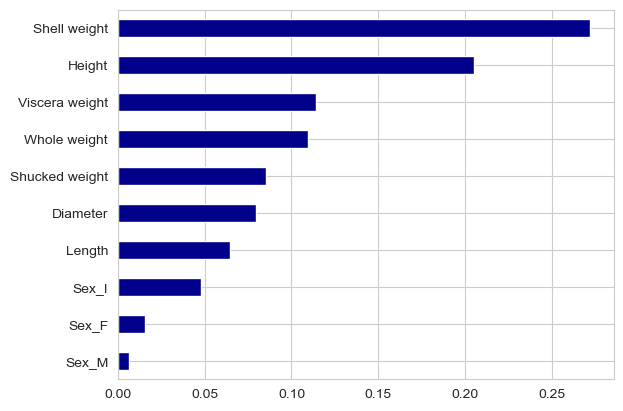

In [56]:
importances_gbc = pd.Series(gs.best_estimator_.feature_importances_, index = X_train_transformed.columns)
sorted_importances_gbc = importances_gbc.sort_values()
sorted_importances_gbc.plot(kind='barh', color='darkblue')
plt.show()

Категориальный признак "Пол" меньше всего влияет на результаты модели случайного леса

Для улучшения модели в дальнейшем можно сделать следущее:
- построить модель регрессии
- трансформировать целевой признак (применить квадратный корень, тогда распределение будет больше похоже на нормальное)
- удалить сильно коррелированные между собой признаки
- применить более сложные модели и расширить диапазон подбора гиперпараметров

**Построение Explainer Dashboard**

In [59]:
# !pip install explainerdashboard -q

In [61]:
# from explainerdashboard import ClassifierExplainer, ExplainerDashboard

In [63]:
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

In [65]:
# explainer = ClassifierExplainer(gs.best_estimator_, X_test_transformed, y_test_full)

In [67]:
# db = ExplainerDashboard(explainer)

In [69]:
# db.run()

Какие факторы наиболее важны в среднем для получения прогноза (вкладка Feature Importances):
1. Вес раковины моллюска в граммах
2. Высота раковины
3. Вес внутренних органов моллюска (неужели они их из 4 тыс. моллюсков выковыривали и взвешивали?)   

Какие значения метрик получились (вкладка Classification Stats)
1. Доля правильных ответов (accuracy) - 79% всех предсказаний верные
2. Точность (precision) - 78,2% доля предсказанных положительных ответов, которые действительно являются положительными
3. Полнота (recall) - 79,6%  доля объектов положительного класса из 
всех объектов положительного класс, которуюа нашел алгорит
Если посмотреть на матрицу ошибок (Confusion Matrix), то можно увидеть, что в около 10% случаев алгоритм старые раковины классифицирует как молодые, а в 11% случаев молодые раковины относит к старым.м

Aнализ 2-3 индивидуальных прогнозов с комментарием

Индекс 2 (моллюск - младенец):

1. Молодой моллюск предсказан правильно. Согласно модели вероятность, что это молодой моллюск - 59,6%
2. Наибольшее по модулю влияние оказывают факторы: Sex_I (пол - младенец), Shucked weight (вес мяса?), Viscera weight (вес внутренних органов)
   
Индекс 853 (моллюск женского пола):

1. Молодой моллюск предсказан правильно. Согласно модели вероятность, что это молодой моллюск - 56,5%
2. Наибольшее по модулю влияние оказывают факторы: Shucked weight (вес мяса?), Sex_I (пол - младенец), Shell weight (вес раковины)
   
Индекс 694 (моллюск женского пола):

1. Старый моллюск предсказан неправильно. Согласно модели вероятность, что это молодой моллюск - 50,3%
2. Наибольшее по модулю влияние оказывают факторы: Shell weight (вес раковины), Sex_I (пол - младенец), Whole weight (вес всего моллюска без расчленения)